E1 = [] | E0 = [50]
E2 = [] | E1 = [67.49294, 37.04091]
E3 = [] | E2 = [91.10594, 50.0, 27.44058]
E4 = [] | E3 = [122.98016, 67.49294, 37.04091, 20.32848]

Affichage des noeuds à chaque étape
E0 = [50]
E1 = [67.49294, 37.04091]
E2 = [91.10594, 50.0, 27.44058]
E3 = [122.98016, 67.49294, 37.04091, 20.32848]
E4 = [166.00585, 91.10594, 50.0, 27.44058, 15.05971]
p : 0.4338 | 1-p : 0.5662 | Coeff d'actualisation : 0.9950

 [114.00585000000001, 39.105940000000004, 0, 0, 0]
[71.23951, 16.87907, 0.0, 0.0]
[40.25816, 7.28541, 0.0]
[21.48091, 3.14456]



Liste des cours de l'action, à chaque étape :
[[50], [67.49, 37.04], [91.11, 50.0, 27.44], [122.98, 67.49, 37.04, 20.33], [166.01, 91.11, 50.0, 27.44, 15.06]]
Valeurs des prix des options : [[11.043287923658681], [21.48091, 3.14456], [40.25816, 7.28541, 0.0], [71.23951, 16.87907, 0.0, 0.0], [114.00585000000001, 39.105940000000004, 0, 0, 0]]
Prix de l'option ajd : 11.0433


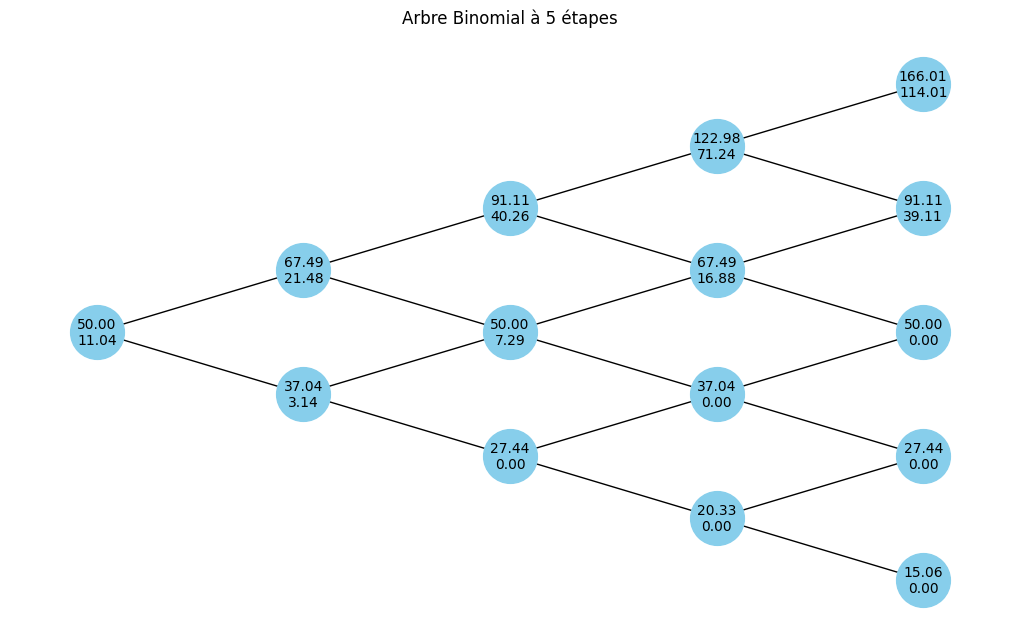

In [2]:
from math import *
import matplotlib.pyplot as plt
import networkx as nx
#Code visant à calculer les prix des actions à chaque branche, soit les prix des actions à chaque période t.

#Détermination du cours actuel du sous-jacent, des coefficients à la hausse et à la baisse.
S_0 = 50
u = exp(0.3)
d = exp(-0.3)


def prix_option(call:bool,put:bool,n,delta_t:float):

    n = int(n/delta_t)

    if call==True and put==True or call==False and put==False:
        return "Veuillez choisir l'option dont vous souhaitiez calculer le prix."

    #Initialisation de la liste des étapes (étape = ensemble des noeuds à une période donnée).
    #On choisit d'utiliser 6 étapes : E0, E1, E2, E3, E4, E5. L'arbre a donc 5 périodes (= t0, t1, t2, t3, t4,t5)
    liste_noms = [[S_0]]+[[] for _ in range(n)]
    #Note : on a mis a0 dans une liste, car la boucle du dessous va itérer sur des objets itérables.



    #I - Calcul de l'ensemble des cours de l'action à chaque noeud
    for k in range(1,n+1,1):    #Pour chaque étape (E1, E2, E3, E4, E5)

        # #Affichage du contenu des étapes pré-remplissage
        #On affiche à quelle date t on est, et les éléments de l'étape précédente que l'on va utiliser pour trouver les cours pour cette étape.
        print(f"E{k} = {liste_noms[k]} | E{k-1} = {liste_noms[k-1]}")
        etape_actuelle = liste_noms[k]
        etape_precedente = liste_noms[k-1]

        #Pour une étape k donnée, on ajoute les évolutions de cours dans l'étape k+1
        for element in etape_precedente: #Pour chaque élément de l'étape précédente (E0 pour E1, E1 pour E2, E2 pour E3)

            #Calcul des évolutions de cours
            prix_hausse = round(element*u,5) #calcul du cours évolué, dans le cas d'une hausse
            prix_baisse = round(element*d,5) #calcul du cours évolué, dans le cas d'une baisse

            #Ajout des évolutions de cours
            if prix_hausse not in etape_actuelle:  #Si le cours évolué à la hausse n'est pas dans l'étape k, on la rajoute
                etape_actuelle.append(prix_hausse)
            if prix_baisse not in etape_actuelle:  #Si le cours évolué à la baisse n'est pas dans l'étape k, on la rajoute
                etape_actuelle.append(prix_baisse)

    #Après avoir calculé l'ensemble des cours possibles (=ensemble des noeuds possibles), on les affiche
    #Affichage des différentes étapes et leur contenu.
    print("\nAffichage des noeuds à chaque étape")
    for j in range(len(liste_noms)):
        print(f"E{j} = {liste_noms[j]}")





    ###########################################################################################################################################
    #II - Calcul du prix de l'option, dans le cas d'un call

    prix_exercice = 52
    r_c = 0.02
    p = (exp(r_c*delta_t)-d)/(u-d)
    coeff_actualisation = exp(-r_c*delta_t)
    print(f"p : {p:.4f} | 1-p : {1-p:.4f} | Coeff d'actualisation : {coeff_actualisation:.4f}")

    #Création des listes qui vont contenir les prix de l'option à chaque étape.
    #Donc :
        #L_5 contient les payoffs finaux (= prix de l'option à la date finale, selon les chemins d'évolutions),
        #L_4 contient les prix de l'option à l'étape E4 <=> contient [f_4u; f_3u1d; f_2u2d; f_1u3d; f_4d],
        #L_3 contient les prix de l'option à l'étape E3 <=> contient [f_3u; f_2u1d; f_1u2d; f_3d],
        #L_2 contient les prix de l'option à l'étape E2 <=> contient [f_2u; f_1u1d; f_2d],
        #L_1 contient les prix de l'option à l'étape E1 <=> contient [f_u; f_d],
        #L_0 contient le prix de l'option aujourd'hui.
    #On crée à part la liste contenant les payoffs finaux, pour "visuellement initialiser", et donc bien distinguer les payoffs finaux des payoffs intermédiaires.
    #liste_payoffs_finaux contient l'ensemble des payoffs finaux d'un call, où le premier indice est le noeud final le plus haut,
    #et le dernier indice est le noeud final le plus bas.
    liste_prix_options = [0]+[[] for _ in range(n)]


    def payoffs_call(): #Fonction qui calcule les payoffs terminaux d'un call
        return [max(0,prix-prix_exercice) for prix in liste_noms[n]]
    def payoffs_put():  #Fonction qui calcule les payoffs terminaux d'un put
        return [max(0,prix_exercice-prix) for prix in liste_noms[n]]

    liste_payoffs_finaux = []
    if call:
        liste_payoffs_finaux = payoffs_call()
    elif put:
        liste_payoffs_finaux = payoffs_put()

    liste_prix_options[n] = liste_payoffs_finaux
    print("\n",liste_payoffs_finaux)



    #Calcul du prix de l'option, à chaque noeud de la date t.
    #Première boucle : pour chaque étape E_k, ...
    for numero_etape in range(n-1,0,-1):
        #Idée : pour chaque noeud de l'étape k-1, on a :
        # - le noeud n°1 de E_k-1 (= noeud le plus haut de E_k-1) qui va utiliser les noeuds n°1 et n°2 de E_k
        # - le noeud n°2 de E_k-1 (= 2e noeud le plus haut de E_k-1) qui va utiliser les noeuds n°2 et n°3 de E_k
        # - le noeud n°3 de E_k-1 (= 3e noeud le plus haut de E_k-1) qui va utiliser les noeuds n°3 et n°4 de E_k
        # - etc.
        #Rappel : E_k = liste_noms[k]. L'étape n°k est l'élément n°k de liste_noms.

        etape = liste_noms[numero_etape]

        #... prendre les noeuds de l'étape E_k+1, et calculer le prix de l'option à chaque noeud de l'étape E_k
        etape_suivant = liste_prix_options[numero_etape+1]
        for noeud in etape: #pour chaque noeud de l'étape E_k :
            #on calcule l'indice du noeud, et on calcule le prix de l'option au noeud n°j en mobilisant les noeuds n°j et j-1 de l'étape suivante
            #puis, on ajoute ce prix de l'option, pour le noeud actuel de l'étape E_k, à la liste L_k.
            indice_noeud = etape.index(noeud)
            prix_option = coeff_actualisation*( (p*etape_suivant[indice_noeud]) + ((1-p)*etape_suivant[indice_noeud + 1]) )
            liste_prix_options[numero_etape].append(round(prix_option,5))

        print(liste_prix_options[numero_etape])

    #Calcul du prix de l'option à la date d'aujourd'hui
    prix_option_ajd = coeff_actualisation*( (p*liste_prix_options[1][0]) + ((1-p)*liste_prix_options[1][1]) )
    liste_prix_options[0] = [prix_option_ajd]
    liste_noms = [[round(liste_noms[j][i],2) for i in range(len(liste_noms[j]))] for j in range(len(liste_noms))]
    print(f"\n\n\nListe des cours de l'action, à chaque étape :\n{liste_noms}")
    print(f"Valeurs des prix des options : {liste_prix_options}") #Affichage des prix de l'option à chaque date/étape.
    print(f"Prix de l'option ajd : {prix_option_ajd:.4f}")    #Affichage du prix de l'option à la date d'aujourd'hui.





    ###############################################
    #Traçage de l'arbre binomial

    graphe = nx.Graph() #graphique
    pos = {}    #pos représente les noeuds du graphe
    labels = {} #labels

    #Génération des nœuds et des positions
    for etape in range(n+1):    #Pour chaque étape, ...
        for index in range(etape + 1):  #Pour chaque noeud/index, on crée un identifiant unique (étape,noeud/index) que l'on ajoute au graphique
            #Identification unique du nœud (étape, index), et ajout de ce noeud au graphe
            node_id = (etape,index)
            graphe.add_node(node_id)

            #Ajout du cours de l'action au noeud actuel
            cours_action = liste_noms[etape][index]
            prix_option = liste_prix_options[etape][index]
            labels[node_id] = f"{cours_action:.2f}\n{prix_option:.2f}"

            #Positionnement (x = étape, y = décalage vertical)
            #Pour l'étape 0 : (0,0)
            #Pour l'étape 1 : (1,1) et (1,-1)
            #Pour l'étape 2 : (2,2) et (2,0) et (2,-2)
            #Pour l'étape 3 : (3,3) et (3,1) et (3,-1) et (3,-3)
            #etc.
            pos[node_id] = (etape,etape-2*index)

            #Si l'index est positif, on ne dessine que les traits/liens vers le haut reliant les noeuds n°i de E_k et n°i-1 de E_k-1
            if index > 0: #Lien vers le haut (lien du noeud n°i de l'étape E_k vers le noeud n°i-1 de l'étape E_k-1)
                graphe.add_edge((etape - 1, index - 1), node_id)
            #Si le numéro d'index est inférieur au numéro de l'étape actuel, on dessine un trait/lien vers le haut reliant les noeuds n°i de E_k et n°i de E_k-1
            if index < etape: #Lien vers le bas (lien du noeud n°i de l'étape E_k vers le noeud n°i de l'étape E_k-1)
                graphe.add_edge((etape - 1, index), node_id)

    plt.figure(figsize=(10, 6))
    nx.draw(graphe, pos, with_labels=False, node_size=1500, node_color="skyblue")
    nx.draw_networkx_labels(graphe, pos, labels, font_size=10)
    plt.title("Arbre Binomial à 5 étapes")
    plt.show()

prix_option(call=True,put=False,n=1,delta_t=0.25)

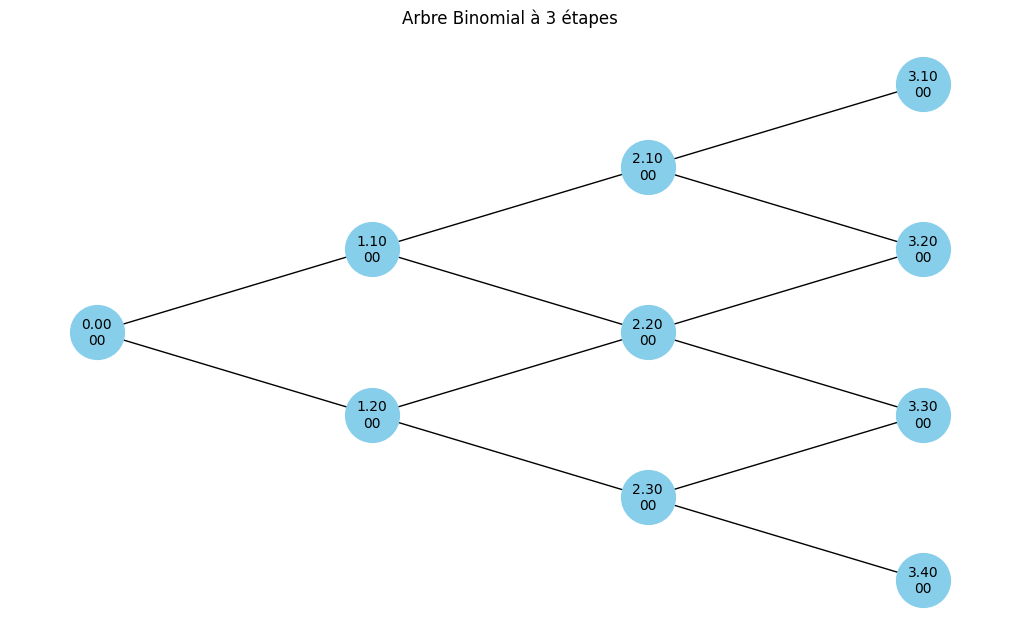

In [1]:
import matplotlib.pyplot as plt
import networkx as nx

graphe = nx.Graph() #graphique

pos = {}    #pos représente les noeuds du graphe
labels = {} #labels
liste_prix = [[0], [1.1,1.2], [2.1,2.2,2.3], [3.1,3.2,3.3,3.4]]
# Génération des nœuds et des positions
for etape in range(3+1):
    for index in range(etape + 1):
        #Identification unique du nœud (étape, index), et ajout de ce noeud au graphe
        node_id = (etape,index)
        graphe.add_node(node_id)

        #Ajout du cours de l'action au noeud actuel
        price = liste_prix[etape][index]
        labels[node_id] = f"{price:.2f}\n00"

        #Positionnement (x = étape, y = décalage vertical)
        #Pour l'étape 0 : (0,0)
        #Pour l'étape 1 : (1,1) et (1,-1)
        #Pour l'étape 2 : (2,2) et (2,0) et (2,-2)
        #Pour l'étape 3 : (3,3) et (3,1) et (3,-1) et (3,-3)
        #etc.
        pos[node_id] = (etape,etape-2*index)

        #Si l'index est positif, on ne dessine que les traits/liens vers le haut reliant les noeuds n°i de E_k et n°i-1 de E_k-1
        if index > 0: #Lien vers le haut (lien du noeud n°i de l'étape E_k vers le noeud n°i-1 de l'étape E_k-1)
            graphe.add_edge((etape - 1, index - 1), node_id)
        #Si le numéro d'index est inférieur au numéro de l'étape actuel, on dessine un trait/lien vers le haut reliant les noeuds n°i de E_k et n°i de E_k-1
        if index < etape: #Lien vers le bas (lien du noeud n°i de l'étape E_k vers le noeud n°i de l'étape E_k-1)
            graphe.add_edge((etape - 1, index), node_id)

plt.figure(figsize=(10, 6))
nx.draw(graphe, pos, with_labels=False, node_size=1500, node_color="skyblue")
nx.draw_networkx_labels(graphe, pos, labels, font_size=10)
plt.title("Arbre Binomial à 3 étapes")
plt.show()